In [1]:
#
# -- PRELIMINARIES / IMPORTS
# -- JUST RUN THIS
#

import os
import sys
sys.path.insert(0, '../')

import numpy             as np
import pandas            as pd
import seaborn           as sns
import matplotlib.pyplot as plt
import PIL.Image         as Image

from   vocal          import Vocal
from   list_of_vocals import ListOfVocals
from   recording      import Recording
from   viz            import Viz, VizGroup

In [2]:
# -- First we load the output object from VocalPy for a number of recording
# -- group the recordings as desired

# -- path to vocalpy object for each group
group1 = [
    '/Users/gustavo/Documents/git/vocalpy/audios/1304_Agrp-Trpv1_1st_outputs/recording_wo_spectrograms.vocalpy',
    '/Users/gustavo/Documents/git/vocalpy/audios/1773_Agrp-Trpv1_1st_Stage_outputs/recording_wo_spectrograms.vocalpy',
    '/Users/gustavo/Documents/git/vocalpy/audios/1303_Agrp-Trpv1_1st_outputs/recording_wo_spectrograms.vocalpy',
]

group2 = [
    '/Users/gustavo/Documents/git/vocalpy/audios/1303_Agrp-Trpv1_1st_outputs/recording_wo_spectrograms.vocalpy',
    '/Users/gustavo/Documents/git/vocalpy/audios/audio_example_outputs/recording_wo_spectrograms.vocalpy',
    '/Users/gustavo/Documents/git/vocalpy/audios/1773_Agrp-Trpv1_1st_Stage_outputs/recording_wo_spectrograms.vocalpy',
]

group3 = [
    '/Users/gustavo/Documents/git/vocalpy/audios/1773_Agrp-Trpv1_1st_Stage_outputs/recording_wo_spectrograms.vocalpy',
]

# -- set group names
group_names = [
    'isolation', 
    'reunion',
    'control',
]

# -- bin size in minutes
bin_size   = 1

# -- this will create a group visualization object called VizObj
VizObj = VizGroup(list_of_groups=[group1, group2, group3], 
                  group_names=group_names,
                  bin_size=bin_size)
print(VizObj)

recording audio_example.wav had no vocals in bin 2
recording audio_example.wav had no vocals in bin 3


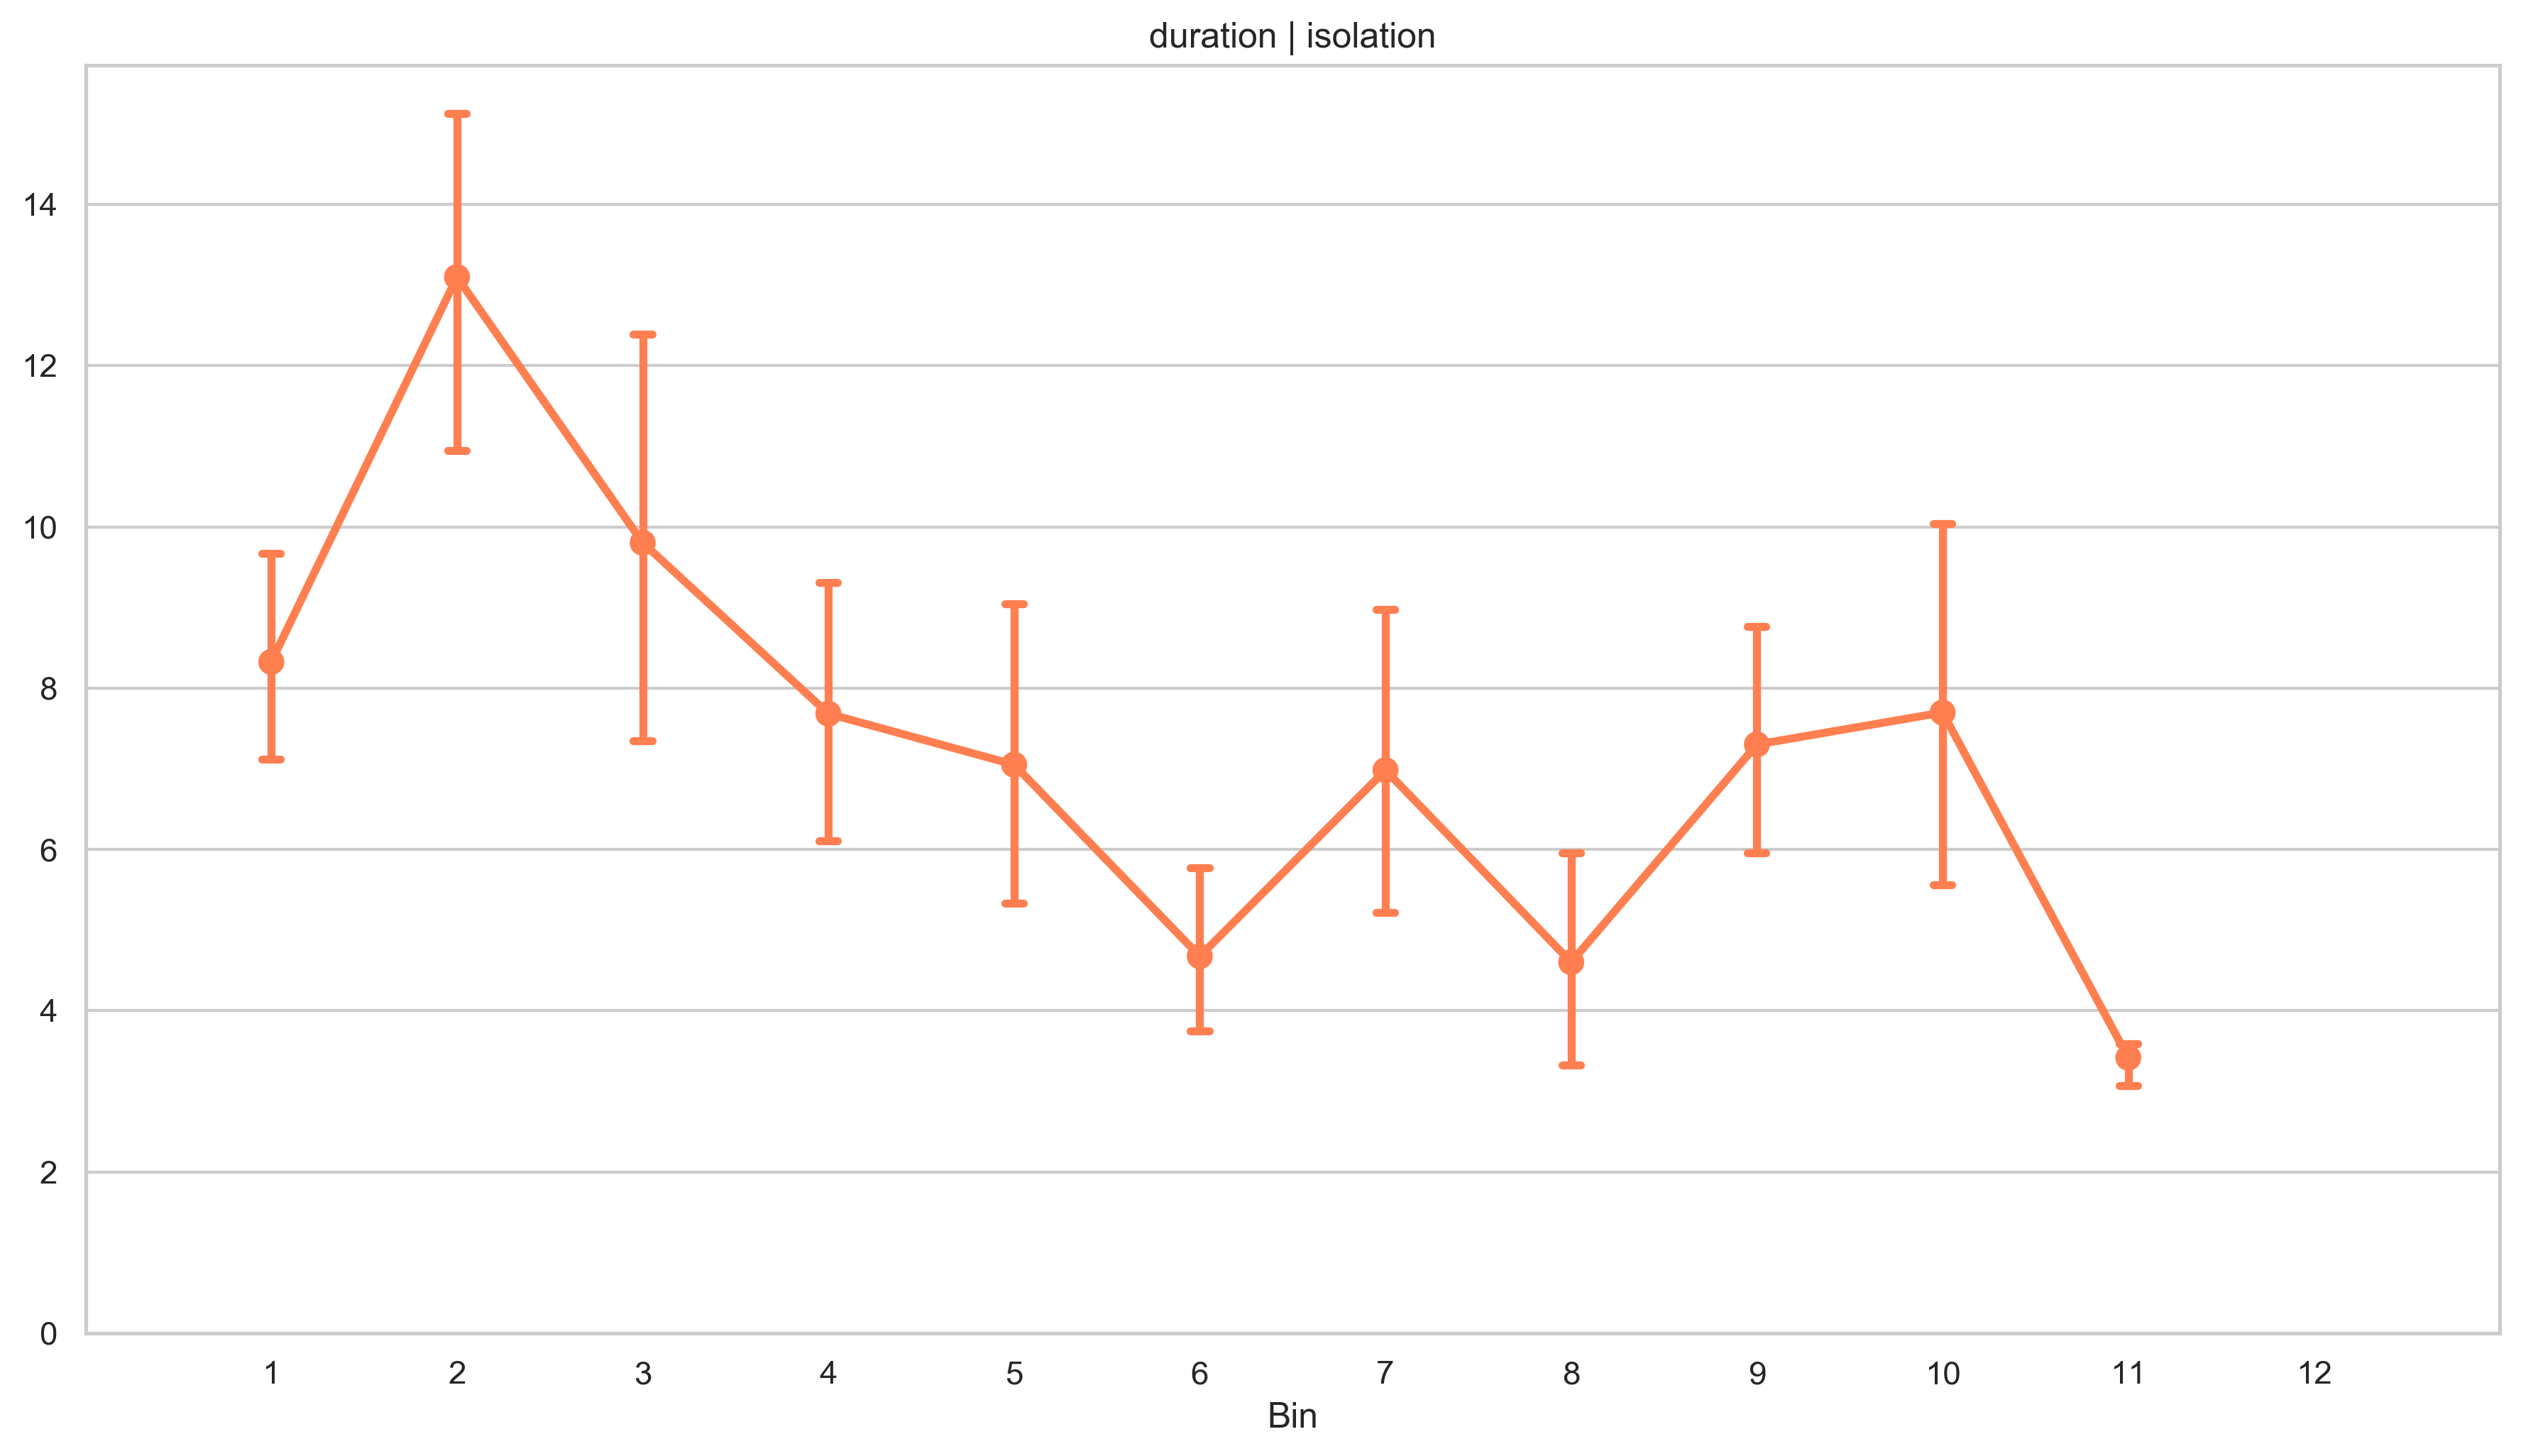

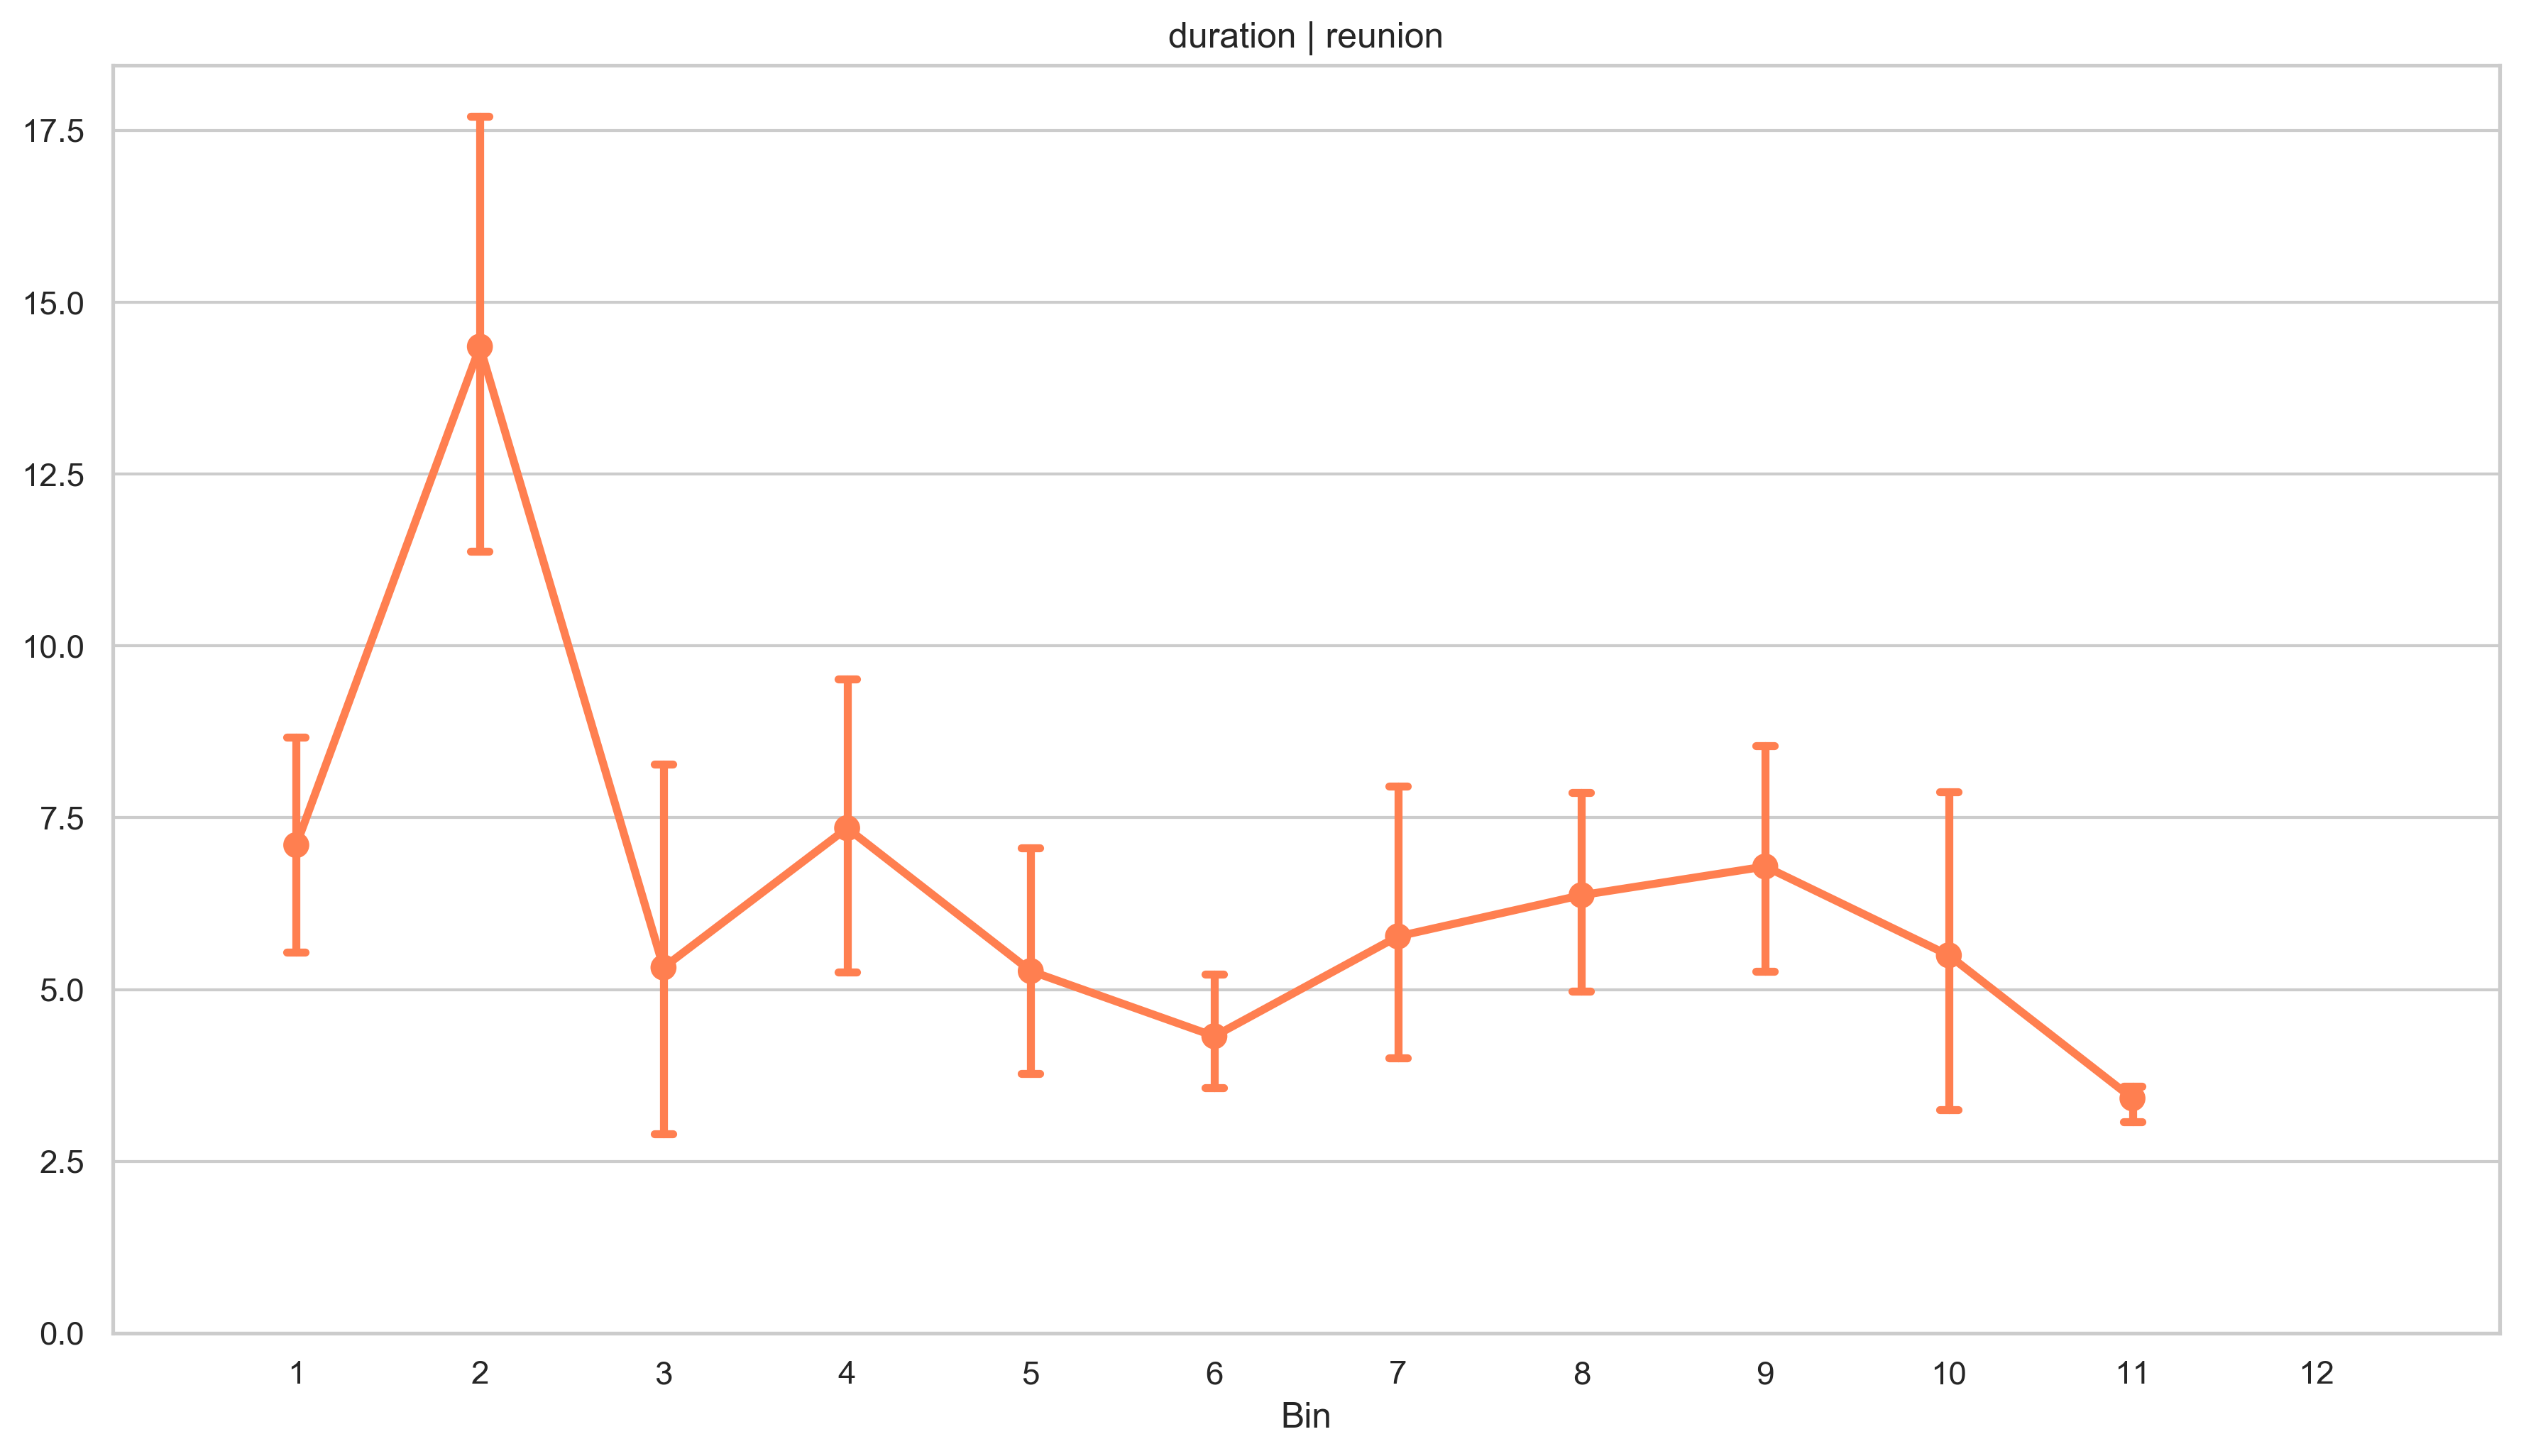

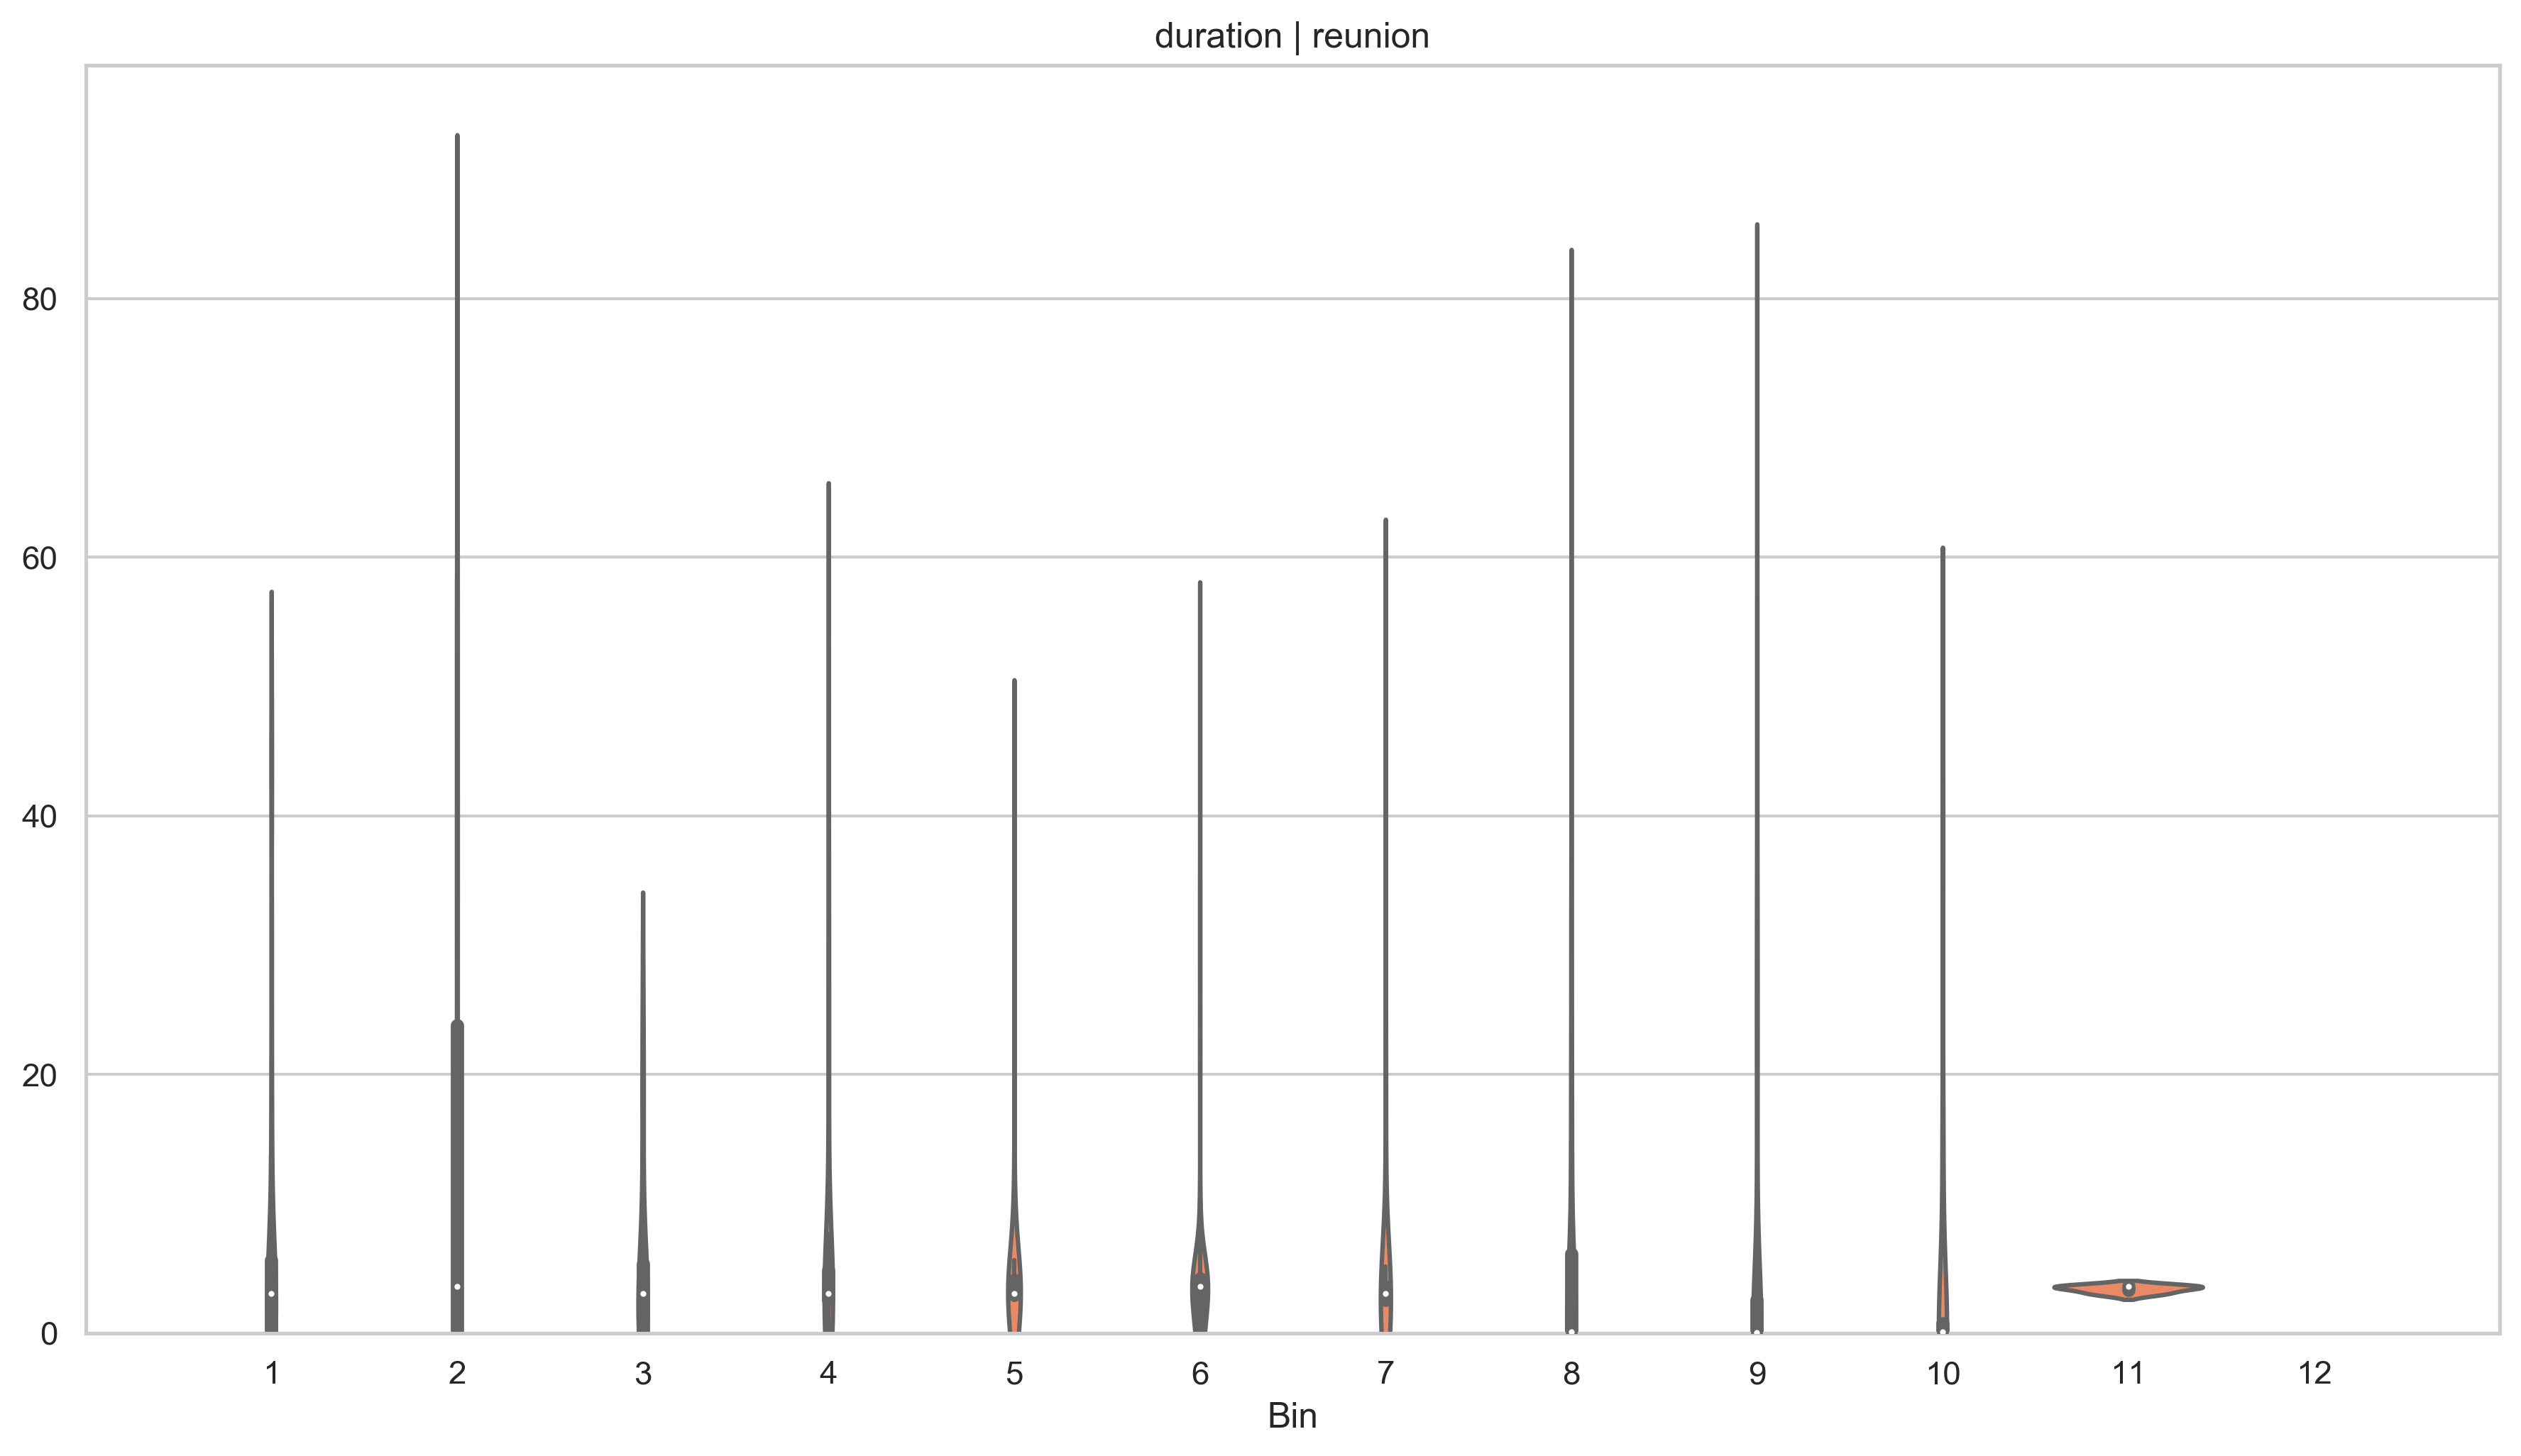

In [5]:
VizObj._list_of_group_viz[0].pointplot(dataname='duration');
VizObj._list_of_group_viz[1].pointplot(dataname='duration');
VizObj._list_of_group_viz[1].violinplot(dataname='duration');

In [3]:
VizObj._list_of_group_viz

[<viz.Viz at 0x1c21800e80>, <viz.Viz at 0x1c2180e630>, []]

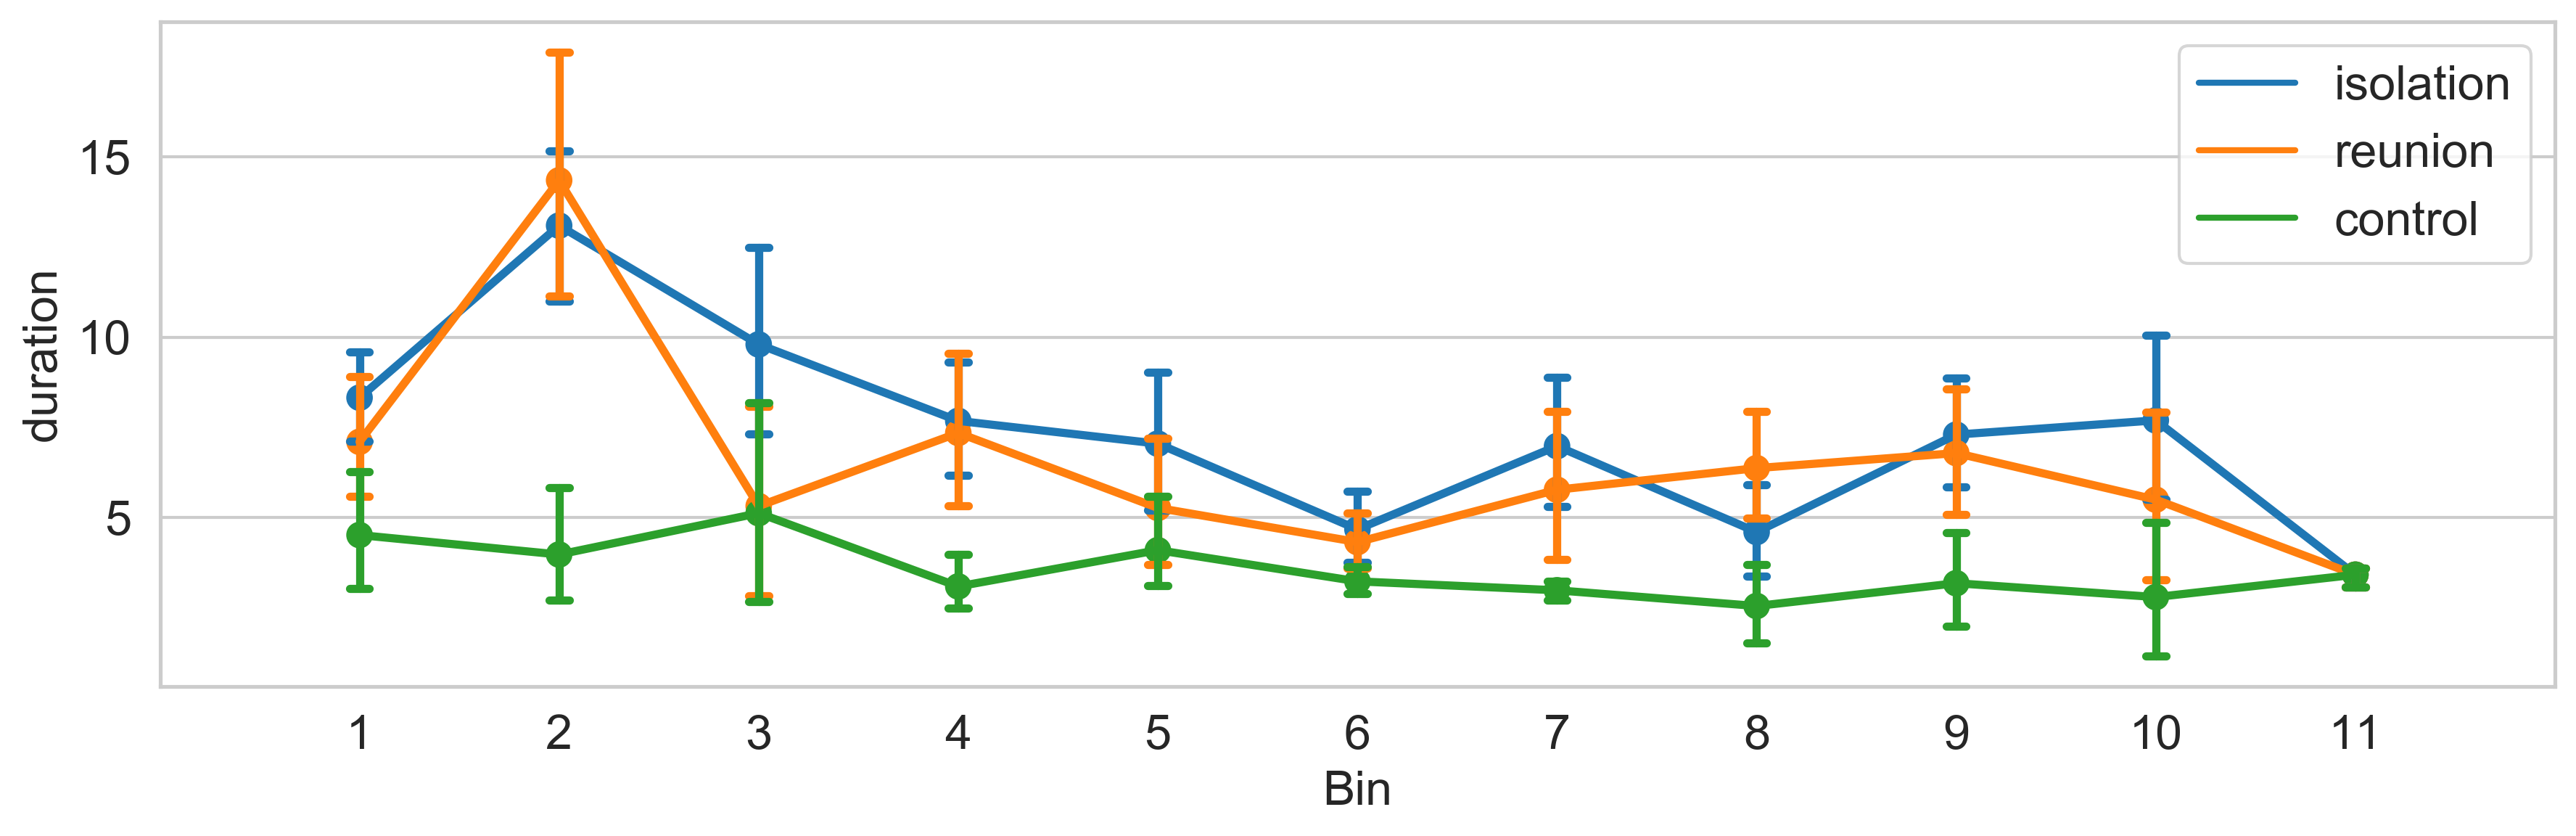

In [3]:
from matplotlib.lines import Line2D


cmap = sns.color_palette()
custom_lines = []

dataname = 'duration'
sns.set(style="whitegrid", palette="muted", color_codes=True)
f, ax = plt.subplots(1, 1, figsize=(12, 4), dpi=300)
labels = []
for i, group in enumerate(VizObj._list_of_group_viz):
    if group:
        data_values = group.get_datapoints(dataname)
        color=np.random.rand(3,)
        sns.pointplot(data=data_values, color=cmap[i], capsize=.1, label=group._recording_data.recording_name)
        custom_lines.append(Line2D([0], [0], color=cmap[i], lw=2))
        labels.append(group._recording_data.recording_name)
        font_size = 16
        ax.set_ylabel(dataname, fontsize=font_size)
        ax.set_xlabel('Bin', fontsize=font_size)
        ax.set_xlim(-1, 11)
        ax.set_xticks(list(range(11)))
        ax.tick_params(labelsize=font_size)
#         ax.set_ylim(45000, 125000)
        plt.tight_layout()

ax.legend(custom_lines, labels, fontsize=font_size)